## Objectifs du projet

Ce projet a pour objectif d’analyser et de prévoir la série temporelle du cours de clôture de l’action **Eurocycles (ECYCL)** cotée à la Bourse de Tunis.  
Les étapes clés sont les suivantes :

1. **Collecte des données**  
   - Extraction automatique des données historiques (dates, cours, volumes) via **web scraping** avec Selenium depuis le site `ilboursa.com`.  
   - Stockage des données dans un fichier CSV puis chargement dans un DataFrame pandas.

2. **Préparation et analyse exploratoire**  
   - Nettoyage, conversion des types, gestion des valeurs manquantes.  
   - Visualisation de l’évolution du prix de clôture.  
   - Décomposition de la série (tendance, saisonnalité, résidus).  
   - Test de stationnarité (ADF) et transformations nécessaires (logarithme, différenciation).

3. **Identification du modèle**  
   - Analyse des fonctions d’autocorrélation (ACF/PACF).  
   - Utilisation de `auto_arima` pour sélectionner les ordres optimaux (ARIMA vs SARIMA).

4. **Modélisation et évaluation**  
   - Construction d’un modèle ARIMA(1,1,0) et d’un modèle SARIMA saisonnier.  
   - Comparaison des performances (RMSE, MAE, MAPE) sur un échantillon de test.

5. **Prévisions futures**  
   - Projection sur 50 jours ouvrables après la fin des données historiques.  

Le but final est de disposer d’un modèle robuste pour anticiper l’évolution du titre Eurocycles, en justifiant le choix du meilleur modèle (ici l’ARIMA simple s’avère plus performant que le SARIMA saisonnier).

### Importation des bibliotheque necessaire 

In [256]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [257]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.ar_model import AR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error, mean_squared_log_error

### Webscrapping des donnees boursier de Eurocycles (collecte de données)

In [ ]:
# importer selenium pour contrôler un navigateur (comme un humain)
from selenium import webdriver

# importer By pour localiser les éléments HTML
from selenium.webdriver.common.by import By

# importer time pour attendre le chargement
import time

# importer pandas pour créer un DataFrame
import pandas as pd

# importer datetime pour gérer les dates
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

# liste pour stocker toutes les données
all_data = []

# ouvrir le navigateur Chrome
driver = webdriver.Chrome()

# ouvrir la page de l'historique Monoprix
driver.get("https://www.ilboursa.com/marches/historiques/ECYCL")

# attendre que la page charge (important pour JS)
time.sleep(5)

# date de début (2010)
start_date = datetime(2010, 1, 1)

# date actuelle
end_date = datetime.today()

# boucle sur toutes les périodes
current_start = start_date

while current_start < end_date:

    # calcul de la date de fin
    current_end = current_start + relativedelta(months=1) 

    if current_end > end_date:
        current_end = end_date

    print(f"Scraping: {current_start} -> {current_end}")

    #  trouver les champs de date sur le site
    date_debut_input = driver.find_element(By.NAME, "datefrom")
    date_fin_input = driver.find_element(By.NAME, "dateto")

    # vider les champs
    date_debut_input.clear()
    date_fin_input.clear()

    # entrer les nouvelles dates
    date_debut_input.send_keys(current_start.strftime("%m/%d/%Y"))
    date_fin_input.send_keys(current_end.strftime("%m/%d/%Y"))

    # cliquer sur le bouton rechercher
    driver.find_element(By.ID, "btnChange").click()

    # attendre chargement des données
    time.sleep(8)

    # récupérer le tableau
    table = driver.find_element(By.ID, "tblhistos")

    # récupérer toutes les lignes
    rows = table.find_elements(By.TAG_NAME, "tr")

    # parcourir les lignes
    for row in rows:
        cols = row.find_elements(By.TAG_NAME, "td")

        # extraire le texte de chaque colonne
        cols = [col.text.strip() for col in cols]

        # ajouter si non vide
        if cols:
            all_data.append(cols)

    # passer à la période suivante
    current_start = current_end

    # petite pause
    time.sleep(1)


# fermer le navigateur
driver.quit()


# créer un DataFrame
df = pd.DataFrame(all_data, columns=[
    "Date", "Ouverture", "Plus Haut", "Plus Bas",
    "Cloture", "Volume", "Valeur", "Variation"
])

# supprimer doublons
df.drop_duplicates(inplace=True)

# afficher les premières lignes
print(df.head())

# sauvegarder en CSV
df.to_csv("EUROCYCLE.csv", index=False)

### Data Preparartion 

In [258]:
df= pd.read_csv('EUROCYCLE.csv',index_col=0, parse_dates=True)
df

C:\Users\hamza\AppData\Local\Temp\ipykernel_7148\948103356.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df= pd.read_csv('EUROCYCLE.csv',index_col=0, parse_dates=True)


,Ouverture,Plus Haut,Plus Bas,Cloture,Volume,Valeur,Variation
Date,,,,,,,
2026-04-13,"11,79","11,50","11,79","11,50",4 044,47 679,"2,52%"
2026-04-10,"11,50","11,30","11,60","11,60",2 852,32 798,"-0,86%"
2026-04-08,"11,60","11,40","11,60","11,45",6 070,70 412,"1,31%"
2026-04-07,"11,45","11,45","11,50","11,49",342,3 916,"-0,35%"
2026-04-06,"11,49","11,26","11,50","11,26",3 410,39 181,"2,04%"
...,...,...,...,...,...,...,...
2026-04-08,11.60,11.45,11.60,11.40,6 070,69 805,1.31%
2026-04-07,11.45,11.49,11.50,11.45,342,3 924,-0.35%
2026-04-06,11.49,11.26,11.50,11.26,3 410,38 806,2.04%


In [259]:
df.index = pd.to_datetime(df.index, format='%d/%m/%Y')
df = df.sort_values('Date', ascending=True)
df = df[(df.index >= '2015-01-01') & (df.index <= '2024-12-31')]
df

,Ouverture,Plus Haut,Plus Bas,Cloture,Volume,Valeur,Variation
Date,,,,,,,
2015-01-05,10.91,11.20,11.20,10.87,7 151,78 899,-2.33%
2015-01-06,10.87,11.13,11.13,10.79,5 693,62 395,-0.37%
2015-01-07,10.82,10.83,11.03,10.82,2 170,23 711,-0.43%
2015-01-08,11.13,10.82,11.17,10.82,41 627,457 619,2.90%
2015-01-09,11.47,11.19,11.78,11.19,11 099,127 491,2.99%
...,...,...,...,...,...,...,...
2024-12-23,11.90,11.86,11.90,11.83,3 999,47 448,0.34%
2024-12-24,11.89,11.90,11.90,11.81,2 752,32 625,-0.08%
2024-12-25,11.88,11.89,11.89,11.79,2 867,33 945,-0.08%


In [260]:
# verifier si il existe des valeur null 
df.isnull().sum()

Ouverture    0
Plus Haut    0
Plus Bas     0
Cloture      0
Volume       0
Valeur       0
Variation    0
dtype: int64

In [261]:
# verifier le typedes donner 
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2440 entries, 2015-01-05 to 2024-12-31
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Ouverture  2440 non-null   object
 1   Plus Haut  2440 non-null   object
 2   Plus Bas   2440 non-null   object
 3   Cloture    2440 non-null   object
 4   Volume     2440 non-null   object
 5   Valeur     2440 non-null   object
 6   Variation  2440 non-null   object
dtypes: object(7)
memory usage: 152.5+ KB


In [262]:
# conversion du type de donnees 
df = df.apply(pd.to_numeric, errors='coerce').astype(float)

### Visualisation de l'evolution de la variable cible (cloture)

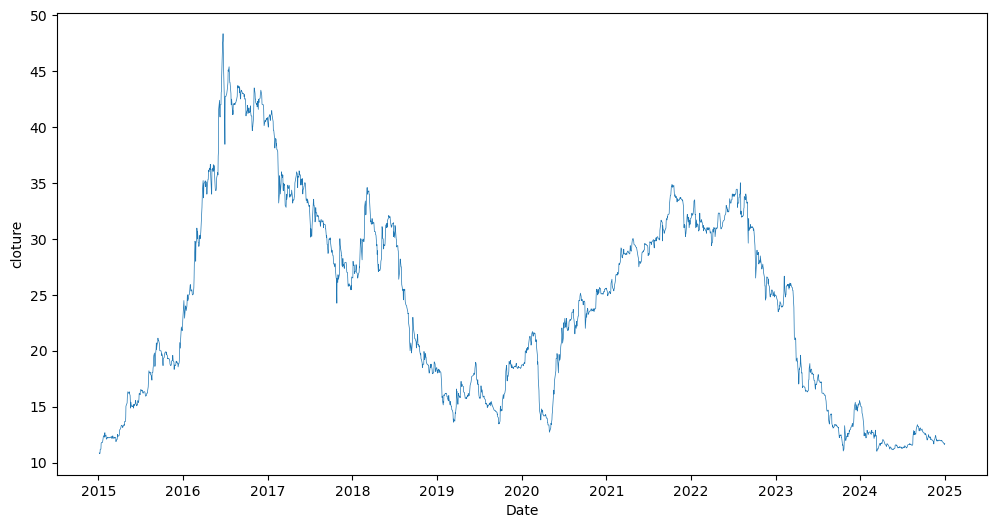

In [263]:
plt.figure(figsize=(12, 6))
plt.plot(df['Cloture'],linewidth = 0.5)           
plt.xlabel('Date')                  
plt.ylabel('cloture')         
plt.show()

In [264]:
# La série présente une tendance générale à la hausse avec des fluctuations importantes. 
#Elle ne semble pas stationnaire (moyenne et variance non constantes).

### Décomposition de la série temporelle

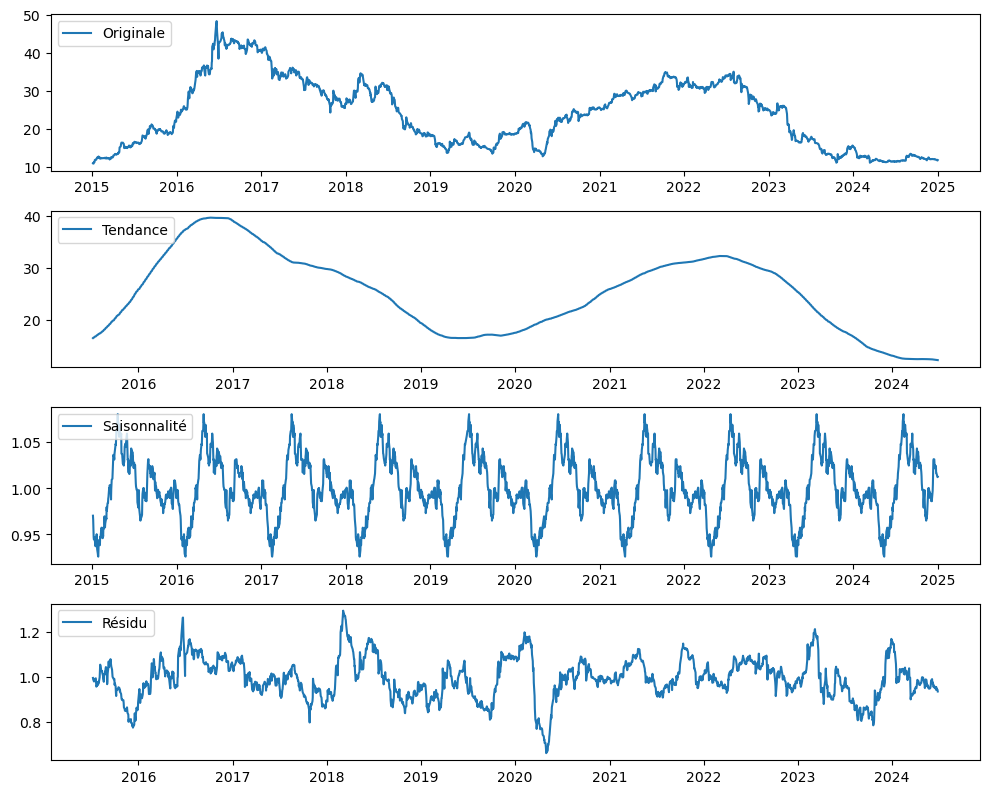

In [265]:
decomposition = seasonal_decompose(df['Cloture'], model="multiplicative",period=252)

# Extraction des composantes
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(10, 8))

plt.subplot(411)
plt.plot(df['Cloture'], label='Originale')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend, label='Tendance')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal, label='Saisonnalité')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual, label='Résidu')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [266]:
# La tendance est fluctuante.

# La saisonnalité montre un cycle régulier 

#Les résidus semblent aléatoires, ce qui est bon signe.

### Test de stationnarite

In [267]:
result = adfuller(df['Cloture'], autolag='AIC')

# Affiche la statistique du test et la valeur p
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

# Interpréter les résultats
if result[1] < 0.05:
    print('La série est stationnaire.')
else:
    print('La série est non-stationnaire.')

ADF Statistic: -1.451324
p-value: 0.557439
La série est non-stationnaire.


### transformation logarithmique 

In [268]:
tl=np.log(df['Cloture'])

In [269]:
# Une transformation logarithmique a été appliquée afin de stabiliser la variance de la série et de réduire l'effet des fluctuations importantes.

In [270]:
# test adf
result = adfuller(tl, autolag='AIC')
# Affiche la statistique du test et la valeur p
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -1.467076
p-value: 0.549731


###### puisque p-value > 0.05 donc: La série est non stationnaire donc on passe a la differenciation de 1er ordre

#### Differenciation du premier ordre

In [271]:
ts_diff =df['Cloture'].diff().dropna()
ts_diff.head()

Date
2015-01-06   -0.08
2015-01-07    0.03
2015-01-08    0.00
2015-01-09    0.37
2015-01-12    0.01
Name: Cloture, dtype: float64

In [272]:
result = adfuller(ts_diff, autolag='AIC')

# Affiche la statistique du test et la valeur p
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

# Interpréter les résultats
if result[1] < 0.05:
    print('La série est stationnaire.')
else:
    print('La série est non-stationnaire.')

ADF Statistic: -25.221123
p-value: 0.000000
La série est stationnaire.


### Visualisation graphique de la serie avant et apres la differenciation 

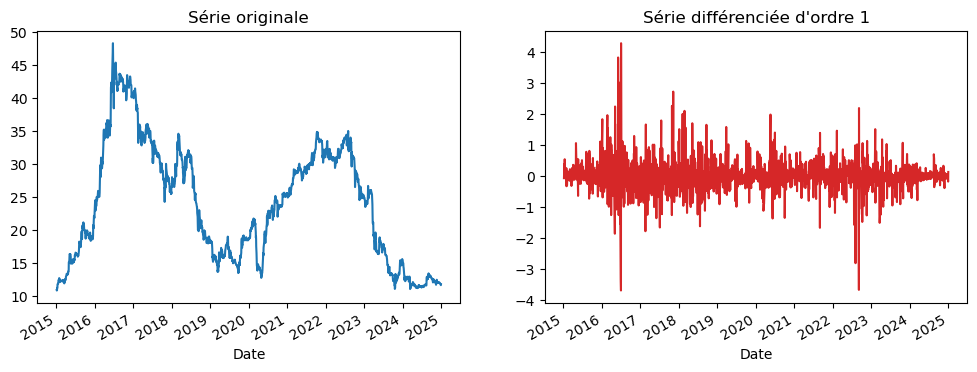

In [273]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Tracé de la série initiale et différenciée
df['Cloture'].plot(title="Série originale",color="tab:blue", ax=ax1)

ts_diff.plot(title="Série différenciée d'ordre 1", color="tab:red", ax=ax2)

plt.show()

###   Les fonctions d'autocorrélation (ACF) et d'autocorrélation partielle (PACF) 

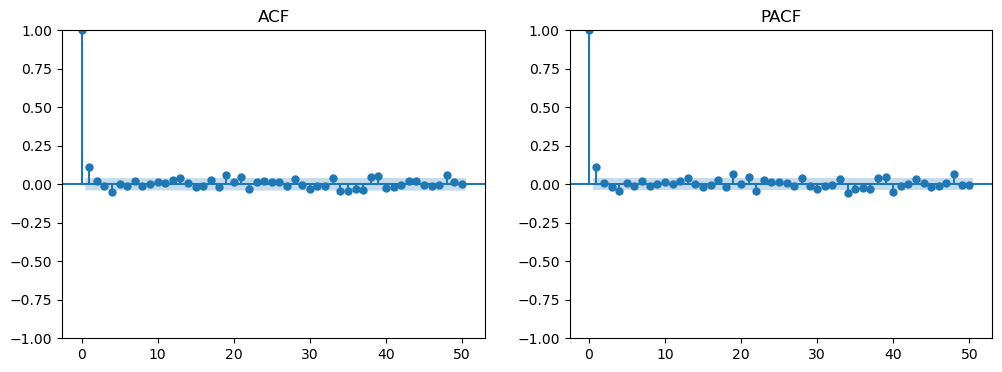

In [274]:
fig, (ax1, ax2)= plt.subplots(1,2, figsize=(12, 4))

plot_acf(ts_diff,lags=50, ax=ax1)
ax1.set_title('ACF')

plot_pacf(ts_diff,lags=50, ax=ax2)
ax2.set_title('PACF')

plt.show()

In [275]:
## Interpretation du ACF ET PACF 
#L’ACF montre une décroissance directe → composante MA (1)
#La PACF a un pic significatif au lag 1 → suggère un modèle AR(1).
#Cela oriente vers un ARIMA(1,1,0).

### Division des donnees (Train 80% /Split 20%)

In [276]:
size= int(len(df)*0.8)
train_ts = df['Cloture'].dropna().iloc[:size] 
test_ts  = df['Cloture'].dropna().iloc[size:] 
print(f'Train : {len(train_ts)} observations, Test : {len(test_ts)} observations')

Train : 1952 observations, Test : 488 observations


In [277]:
!pip install pmdarima

### choix du meilleur model avec auto_arima

In [278]:
from pmdarima import auto_arima

In [279]:
auto_model = auto_arima(train_ts, start_p=0,d=1,start_q=0,
         max_p=5,max_d=5,max_q=5)
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1952
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -1331.694
Date:                Wed, 10 Jun 2026   AIC                           2667.389
Time:                        16:13:08   BIC                           2678.541
Sample:                             0   HQIC                          2671.489
                               - 1952                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0922      0.009     10.331      0.000       0.075       0.110
sigma2         0.2293      0.003     86.805      0.000       0.224       0.234
Ljung-Box (L1) (Q):                   0.00   Jarque-

In [280]:
#L’algorithme recommande un ARIMA(1,1,0) avec un AIC de 2667, ce qui confirme notre analyse graphique.

### Prediction avec le best model ARIMA 

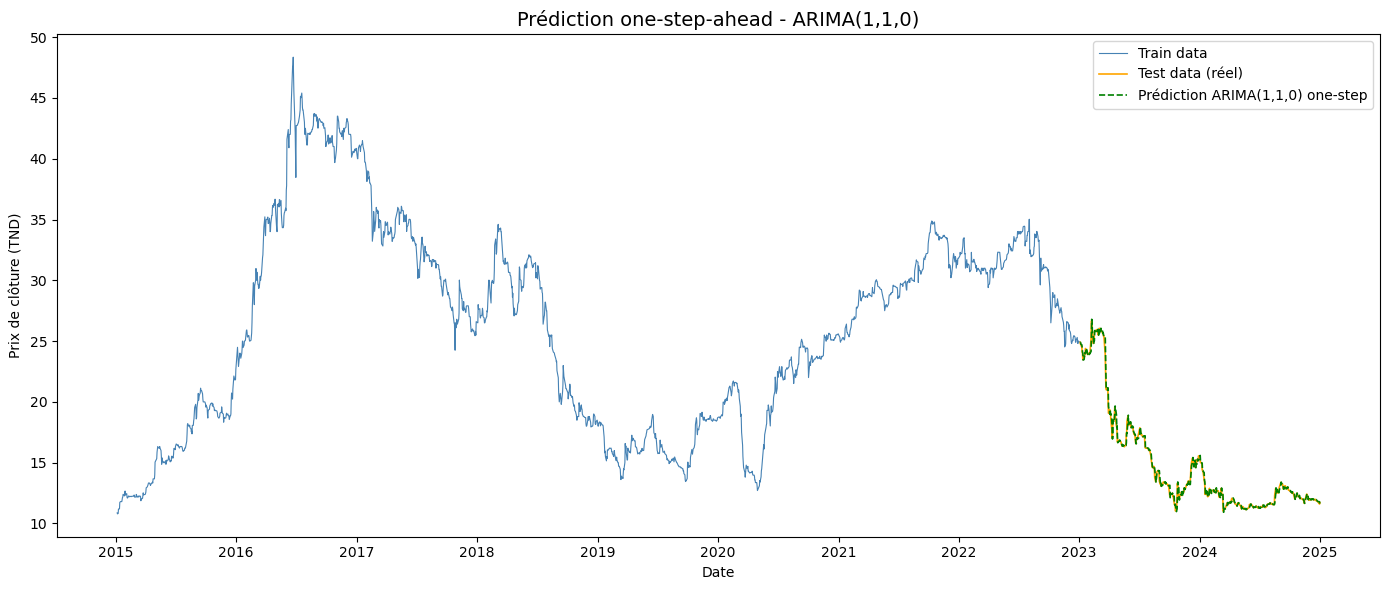

In [281]:
history = list(train_ts)
predictions = []

for i in range(len(test_ts)):
    model_temp = ARIMA(history, order=(1,1,0)).fit()
    yhat = model_temp.forecast(steps=1)[0]
    predictions.append(yhat)
    history.append(test_ts.iloc[i])  

prediction_walk = pd.Series(predictions, index=test_ts.index)

# Graphique
plt.figure(figsize=(14, 6))
plt.plot(train_ts.index, train_ts, label='Train data', color='steelblue', linewidth=0.8)
plt.plot(test_ts.index, test_ts, label='Test data (réel)', color='orange', linewidth=1.2)
plt.plot(prediction_walk.index, prediction_walk, label='Prédiction ARIMA(1,1,0) one-step', 
         color='green', linewidth=1.2, linestyle='--')
plt.title('Prédiction one-step-ahead - ARIMA(1,1,0)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Prix de clôture (TND)')
plt.legend()
plt.tight_layout()
plt.show()

### Evaluation du modele 

In [282]:
# Métriques
rmse_arima = np.sqrt(mean_squared_error(test_ts, prediction_walk))
mae_arima  = mean_absolute_error(test_ts, prediction_walk)
mape_arima = np.mean(np.abs((test_ts.values - prediction_walk.values) / test_ts.values)) * 100
print(f"RMSE : {rmse_arima:.4f}")
print(f"MAE  : {mae_arima:.4f}")
print(f"MAPE : {mape_arima:.2f}%")

RMSE : 0.2849
MAE  : 0.1690
MAPE : 1.11%


In [283]:
# Les erreurs sont faibles (MAPE ≈ 1,1 %), le modèle ARIMA simple est déjà très performant.

###  Tentative avec un modèle SARIMA saisonnier

In [284]:
##Puisque il existe une saisnalite  on va teste le modele Sarima 

In [285]:
model = auto_arima(train_ts, 
        start_p=3,d=1,start_q=0,
         max_p=3,max_d=1,max_q=0,
        start_P=0,D=1, start_Q=0,
        max_P=5,max_D=5,max_Q=5, 
        m=5,seasonal=True)
print(model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                 1952
Model:             SARIMAX(1, 1, 0)x(5, 1, 0, 5)   Log Likelihood               -1487.317
Date:                           Wed, 10 Jun 2026   AIC                           2988.634
Time:                                   16:15:17   BIC                           3027.649
Sample:                                        0   HQIC                          3002.979
                                          - 1952                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0787      0.009      8.423      0.000       0.060       0.097
ar.S.L5       -0.8255      0.019    -43.217

In [286]:
# differenciation d'ordre 5 
ts_diff_S = ts_diff.diff(5).dropna()

In [287]:
# test de stationnarite
result = adfuller(ts_diff_S, autolag='AIC')

# Affiche la statistique du test et la valeur p
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

# Interpréter les résultats
if result[1] < 0.05:
    print('La série est stationnaire.')
else:
    print('La série est non-stationnaire.')

ADF Statistic: -15.127546
p-value: 0.000000
La série est stationnaire.


### ACF et PACF du modele Sarima 

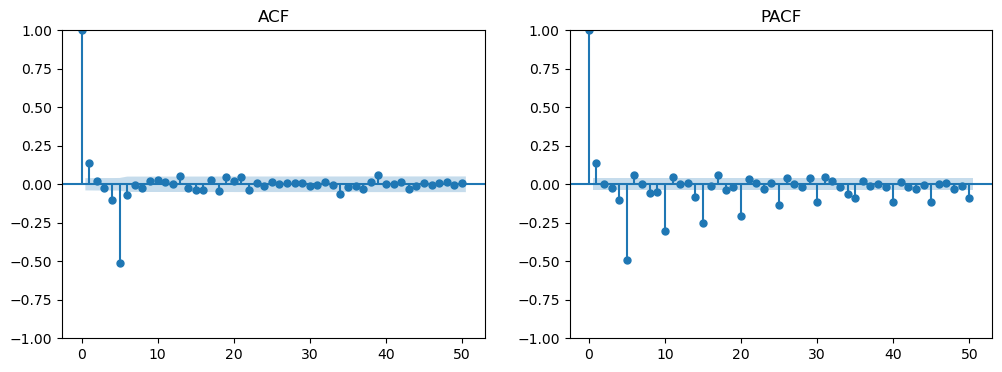

In [288]:
fig, (ax1, ax2)= plt.subplots(1,2, figsize=(12, 4))
plot_acf(ts_diff_S, lags=50, ax=ax1)
ax1.set_title('ACF')
plot_pacf(ts_diff_S, lags=50, ax=ax2)
ax2.set_title('PACF')

plt.show()

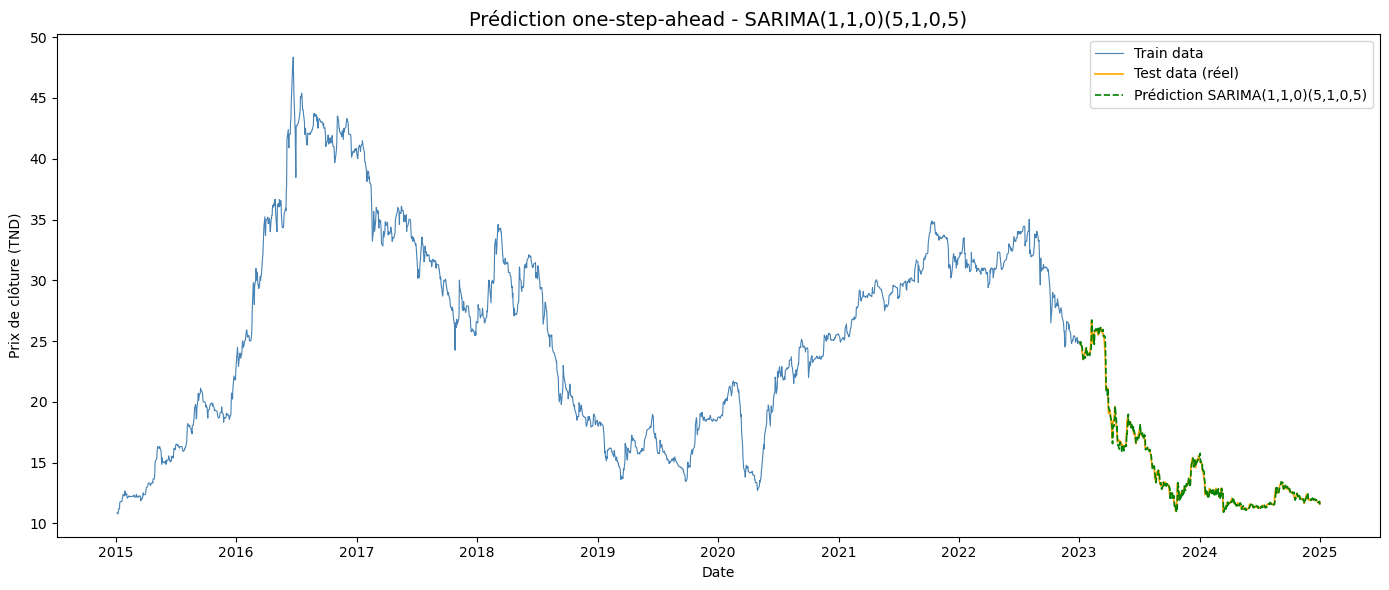

In [289]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

history_s = list(train_ts.values)  
predictions_sarima = []
model_fit = None
REFIT_EVERY = 10  

for i in range(len(test_ts)):
  
    if i % REFIT_EVERY == 0:
        model_fit = SARIMAX(history_s,
                            order=(1, 1, 0),
                            seasonal_order=(5, 1, 0, 5)).fit(
                                disp=False,
                                method='powell',      
                                maxiter=50           
                            )
    else:
       
        model_fit = model_fit.append([test_ts.iloc[i-1]], refit=False)

    yhat_s = model_fit.forecast(steps=1)[0]
    predictions_sarima.append(yhat_s)
    history_s.append(test_ts.iloc[i])

pred_sarima_walk = pd.Series(predictions_sarima, index=test_ts.index)


# GRAPHIQUE

plt.figure(figsize=(14, 6))
plt.plot(train_ts.index, train_ts, label='Train data', color='steelblue', linewidth=0.8)
plt.plot(test_ts.index, test_ts, label='Test data (réel)', color='orange', linewidth=1.2)
plt.plot(pred_sarima_walk.index, pred_sarima_walk,
         label='Prédiction SARIMA(1,1,0)(5,1,0,5)',
         color='green', linewidth=1.2, linestyle='--')
plt.title('Prédiction one-step-ahead - SARIMA(1,1,0)(5,1,0,5)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Prix de clôture (TND)')
plt.legend()
plt.tight_layout()
plt.show()

### Evaluation du modele Sarima 

In [290]:
# MÉTRIQUES
rmse_s = np.sqrt(mean_squared_error(test_ts, pred_sarima_walk))
mae_s  = mean_absolute_error(test_ts, pred_sarima_walk)
mape_s = np.mean(np.abs((test_ts.values - pred_sarima_walk.values) / test_ts.values)) * 100
print(f"RMSE_s : {rmse_s:.4f}")
print(f"MAE_s  : {mae_s:.4f}")
print(f"MAPE_s : {mape_s:.2f}%")

RMSE_s : 0.3077
MAE_s  : 0.1967
MAPE_s : 1.30%


### Comparaison entre le modele ARIMA et SARIMA 

In [291]:
print("\n" + "="*50)
print(f"{'Modèle':<25} {'RMSE':>8} {'MAE':>8} {'MAPE':>8}")
print("="*50)
print(f"{'ARIMA(1,1,0)':<25} {rmse_arima:>8.4f} {mae_arima:>8.4f} {mape_arima:>7.2f}%")
print(f"{'SARIMA(1,1,0)(5,1,0,5)':<25} {rmse_s:>8.4f} {mae_s:>8.4f} {mape_s:>7.2f}%")
print("="*50)


Modèle                        RMSE      MAE     MAPE
ARIMA(1,1,0)                0.2849   0.1690    1.11%
SARIMA(1,1,0)(5,1,0,5)      0.3077   0.1967    1.30%


#####  le modèle ARIMA(2,1,1) présente les valeurs les plus faibles pour les trois indicateurs d'erreur (RMSE, MAE et MAPE). Comme ces indicateurs mesurent l'écart entre les valeurs prédites et les valeurs réelles, des valeurs plus faibles traduisent une meilleure précision des prévisions.
##### Le RMSE est plus faible pour ARIMA (0.2851 contre 0.3077), ce qui signifie que les erreurs importantes sont mieux maîtrisées.
##### Le MAE est également plus faible (0.1692 contre 0.1967), indiquant une erreur moyenne plus réduite.
##### Le MAPE de 1.11 % montre que les prévisions du modèle ARIMA s'écartent en moyenne de seulement 1.11 % des valeurs observées, contre 1.30 % pour le modèle SARIMA.

##### Le modèle ARIMA(2,1,1) est retenu comme meilleur modèle de prévision car il offre la meilleure performance sur l'ensemble des critères d'évaluation. Malgré l'introduction d'une composante saisonnière dans le modèle SARIMA, celle-ci n'apporte pas d'amélioration de la qualité des prévisions. Les résultats suggèrent donc que la dynamique de la série est suffisamment capturée par le modèle ARIMA sans qu'il soit nécessaire d'ajouter une structure saisonnière.

### Comparaison des valeur reel vs predite avec le meilleur modéle 

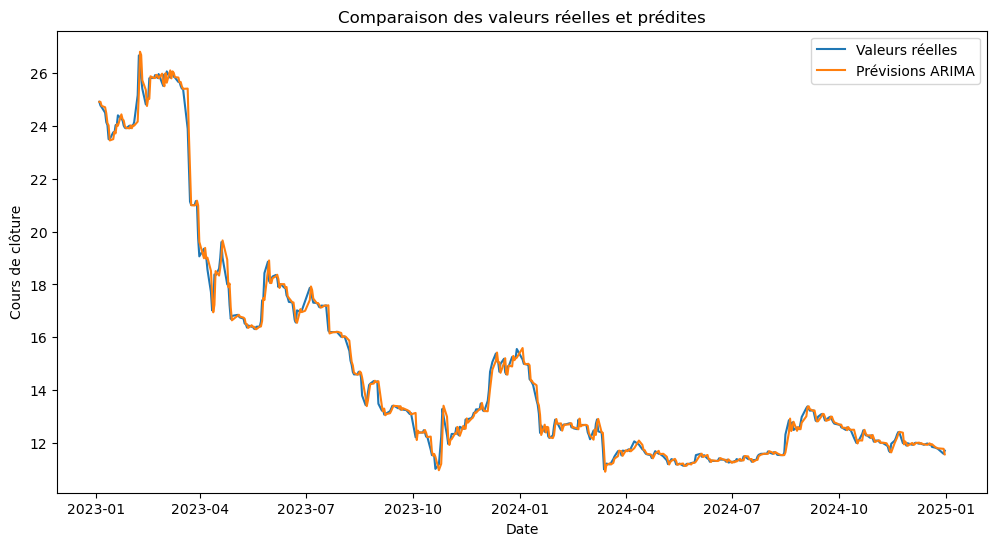

In [292]:
forecast_30 = model_fit.forecast(steps=30)

plt.figure(figsize=(12,6))

plt.plot(test_ts.index,
         test_ts,
         label='Valeurs réelles')

plt.plot(test_ts.index,
         prediction_walk,
         label='Prévisions ARIMA')

plt.title("Comparaison des valeurs réelles et prédites")
plt.xlabel("Date")
plt.ylabel("Cours de clôture")
plt.legend()

plt.show()

### Prévisions sur 50 jours futurs

C:\Users\hamza\Downloads\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Prévisions :
 2025-01-01    11.733291
2025-01-02    11.734763
2025-01-03    11.734926
2025-01-06    11.734944
2025-01-07    11.734946
Freq: B, dtype: float64


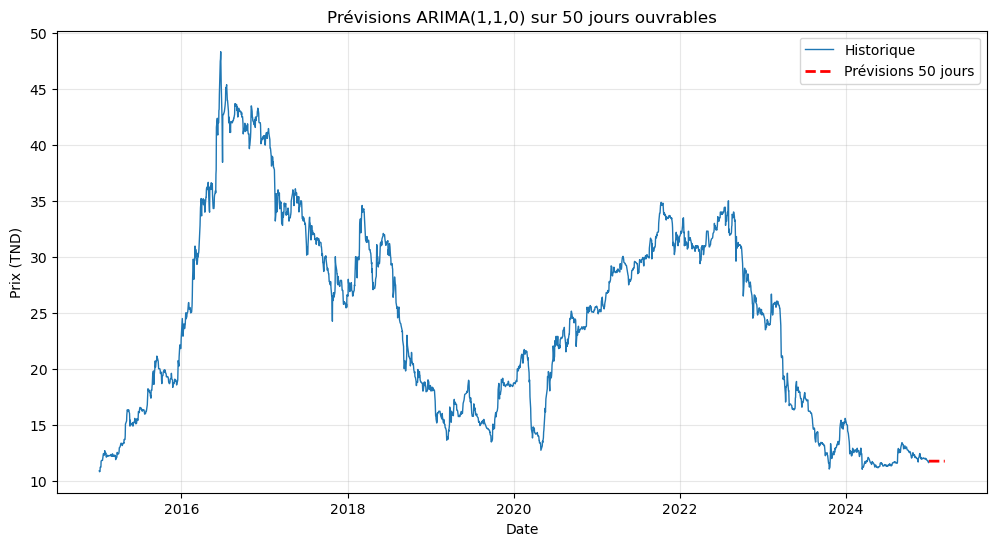

In [295]:
from pandas.tseries.offsets import BDay

# Dernier modèle ARIMA
final_model = ARIMA(df['Cloture'], order=(1,1,0)).fit()

# Prévision
forecast_50 = final_model.forecast(steps=50)

# Génération des dates futures (jours ouvrables à partir du prochain jour ouvrable)
last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date + BDay(1), periods=50, freq='B')
forecast_series = pd.Series(forecast_50.values, index=forecast_index)

# Vérification rapide
print("Prévisions :\n", forecast_series.head())

# Tracé
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Cloture'], label='Historique', linewidth=1)
plt.plot(forecast_series.index, forecast_series, label='Prévisions 50 jours', 
         color='red', linestyle='--', linewidth=2)
plt.title('Prévisions ARIMA(1,1,0) sur 50 jours ouvrables')
plt.xlabel('Date')
plt.ylabel('Prix (TND)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()